In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
simulation_file = '../bulkTemp.dat'

x, y = np.loadtxt(simulation_file, skiprows=4, usecols=(0,1)).T

In [3]:
k_w = 20.4 ; q1 = 0.04e+06 ; L = 0.023 ;

## Nussell number

In [4]:
Tav_file = '../report_postprocess/lineX_y0_zm0.023_T_code.csv'
# 1. Read the CSV file (assumes 1st line is the header)
df = pd.read_csv(Tav_file); 

# 2. Define the columns you want to plot
# Replace these with your actual column names from the CSV header
x_col = 'Points_0'
y_col = 'T' 

# Interpolate directly
y_new = np.interp(x , df[x_col], df[y_col])



In [5]:
paper_data =  '../postprocessing_Mistrangelo/Fig18.csv'

# 1. Read the CSV file (assumes 1st line is the header)
paper = pd.read_csv(paper_data) ;


In [6]:
h = q1 / abs( y - y_new + 1e-10)  # L=a=0.023 ;
Nu = h *(L / k_w) ;

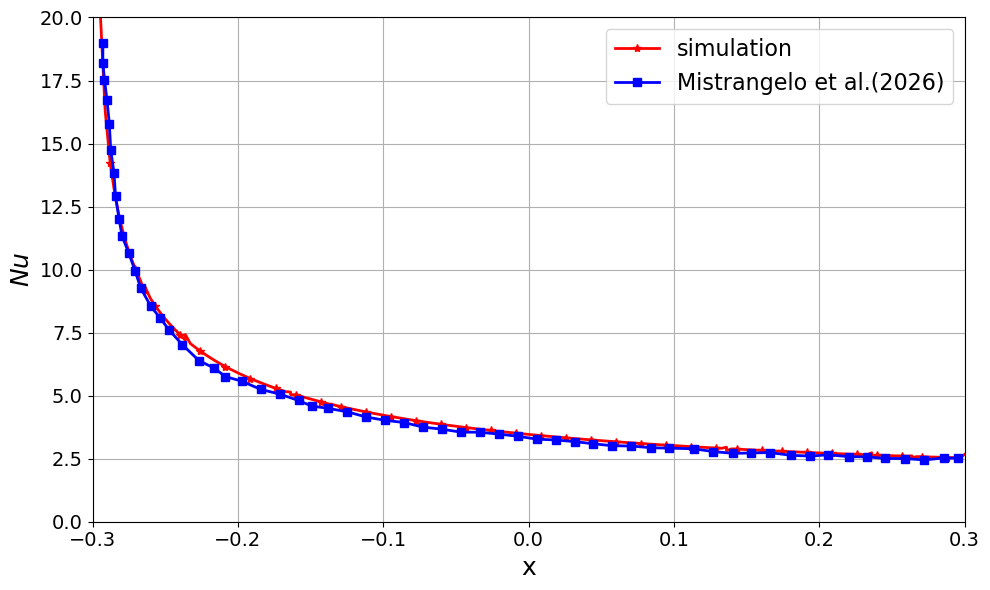

In [7]:
# 3. Create the plot with big font sizes
plt.figure(figsize=(10, 6))

# Use the plot function from matplotlib
plt.plot(x, Nu[:],'r-*',markevery=5,label=f'simulation', linewidth=2)
plt.plot(paper.iloc[:,0], paper.iloc[:,1],'bs-', label=f'Mistrangelo et al.(2026)', linewidth=2)
# 4. Set labels and title with big fontsize
plt.xlabel(r'x', fontsize=18) ; plt.ylabel(r'$Nu$', fontsize=18)
# 5. Add a legend with big fontsize
plt.legend(fontsize=16, loc='best')
# 6. Increase tick label sizes
plt.xticks(fontsize=14) ; plt.yticks(fontsize=14)
plt.xlim([-0.3,0.3]), plt.ylim([0,20])
plt.grid(True)
plt.tight_layout()
plt.savefig('./Nusselt_x.png', dpi=300,bbox_inches='tight')

## AvgKE

In [8]:
simulation_file = '../AvgKE.dat'

x, y = np.loadtxt(simulation_file, skiprows=4, usecols=(0,1)).T

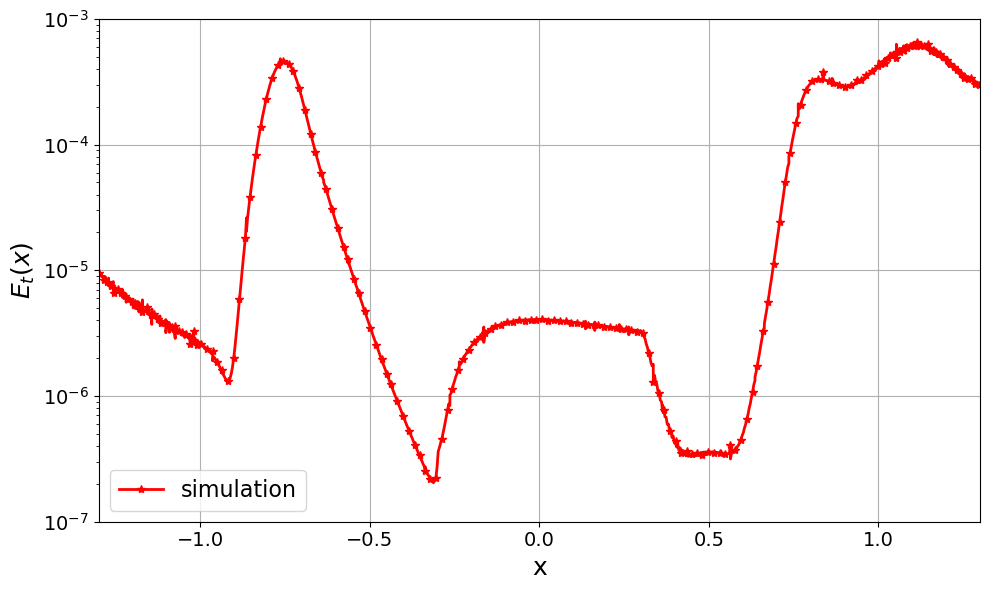

In [9]:
# 3. Create the plot with big font sizes
plt.figure(figsize=(10, 6))

# Use the plot function from matplotlib
plt.plot(x, y,'r-*',markevery=5,label=f'simulation', linewidth=2)
plt.yscale('log')
# 4. Set labels and title with big fontsize
plt.xlabel(r'x', fontsize=18) ; plt.ylabel(r'$E_t(x)$', fontsize=18)
# 5. Add a legend with big fontsize
plt.legend(fontsize=16, loc='best')
# 6. Increase tick label sizes
plt.xticks(fontsize=14) ; plt.yticks(fontsize=14)
plt.xlim([-1.3,1.3]) ; plt.ylim(1e-7, 1e-3)  
plt.grid(True)
plt.tight_layout()
plt.savefig('./AvgKE_x.png', dpi=300,bbox_inches='tight')